# Assignment 1: Basic EDA

1. Read in the "Computers.csv" file. 
2. Explore the target variable, "price". Look at a histogram and boxplot of it.
3. Then, produce histograms of the 'speed' and 'ram' variables. 
4. Feel free to further explore the dataset!

In [1]:
import pandas as pd

computers = pd.read_csv("../Data/Computers.csv")

computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


In [8]:
computers.describe()

,price,speed,hd,ram,screen,ads,trend
count,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000
mean,2219.576610,52.011024,416.601694,8.286947,14.608723,221.301007,15.926985
std,580.803956,21.157735,258.548445,5.631099,0.905115,74.835284,7.873984
min,949.000000,25.000000,80.000000,2.000000,14.000000,39.000000,1.000000
25%,1794.000000,33.000000,214.000000,4.000000,14.000000,162.500000,10.000000
50%,2144.000000,50.000000,340.000000,8.000000,14.000000,246.000000,16.000000
75%,2595.000000,66.000000,528.000000,8.000000,15.000000,275.000000,21.500000
max,5399.000000,100.000000,2100.000000,32.000000,17.000000,339.000000,35.000000


In [9]:
computers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   price    6259 non-null   int64 
 1   speed    6259 non-null   int64 
 2   hd       6259 non-null   int64 
 3   ram      6259 non-null   int64 
 4   screen   6259 non-null   int64 
 5   cd       6259 non-null   object
 6   multi    6259 non-null   object
 7   premium  6259 non-null   object
 8   ads      6259 non-null   int64 
 9   trend    6259 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 489.1+ KB


<Axes: xlabel='price', ylabel='Count'>

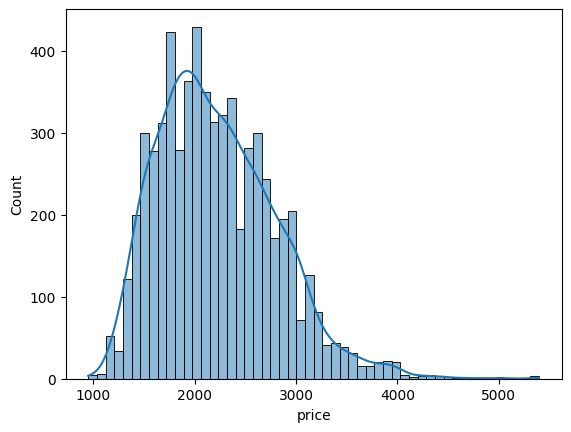

In [11]:
import seaborn as sns

sns.histplot(computers['price'], kde=True)

<Axes: xlabel='price'>

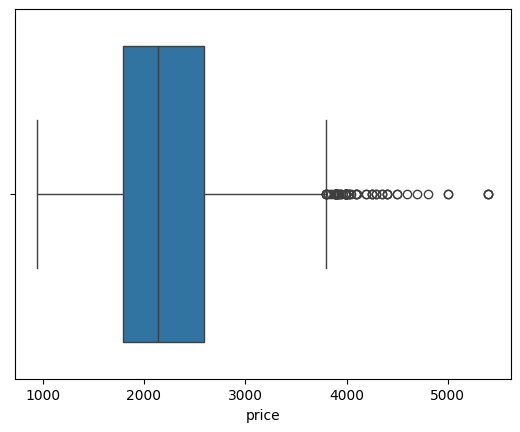

In [13]:
sns.boxplot(x=computers['price'])

<Axes: xlabel='speed', ylabel='Count'>

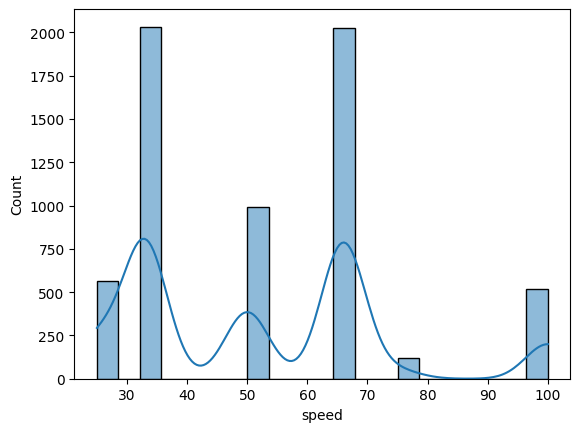

In [14]:
sns.histplot(computers['speed'], kde=True)

<Axes: xlabel='ram', ylabel='Count'>

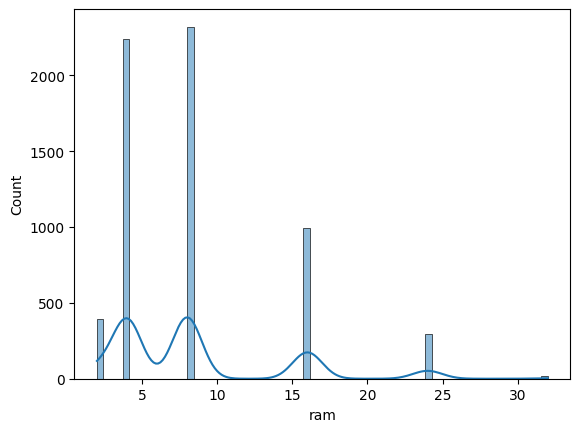

In [15]:
sns.histplot(computers['ram'], kde=True)

In [23]:
computers['ram'].value_counts()

ram
8     2320
4     2236
16     996
2      394
24     297
32      16
Name: count, dtype: int64

<Axes: xlabel='ads', ylabel='Count'>

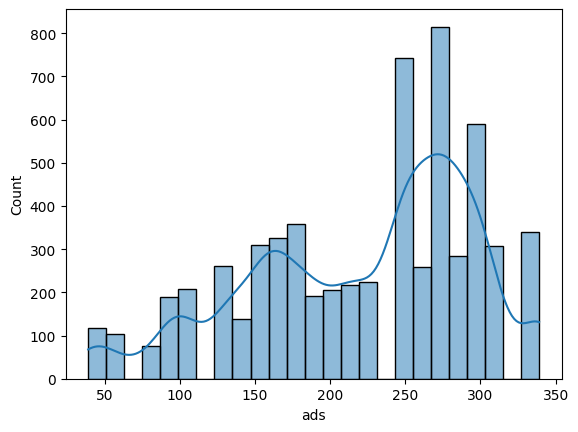

In [16]:
sns.histplot(computers['ads'], kde=True)

<Axes: xlabel='hd', ylabel='Count'>

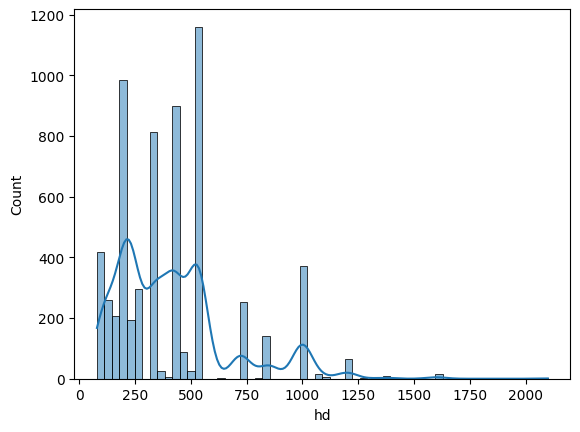

In [17]:
sns.histplot(computers['hd'], kde=True)

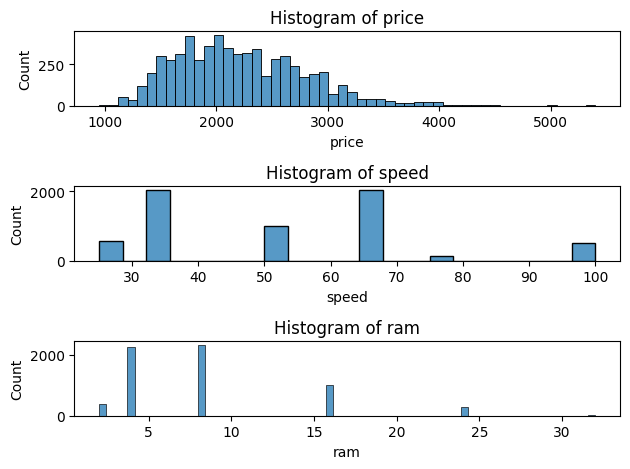

In [ ]:
import matplotlib.pyplot as plt
columns = ['price', 'speed', 'ram']
data = computers

fig, ax = plt.subplots(len(columns), layout='tight')

for col , ax in zip(columns, ax.flat):
    sns.histplot(data=data, x=col, ax=ax)
    ax.set_title(f'Histogram of {col}')

# 대부분의 컴퓨터는 중저가이고, 고가 컴퓨터는 드물다, 오른쪽으로 꼬리가 늘어져있다 (종모양이 아니니 로그변환이 필요할 것 같다)
# 속도는 특정 6개의 속도에만 고정되어 있다
# RAM은 2의 배수 값만 존재하고 4와 8이 가장 흔하다

## Assignment 2: Variable Relationships

1. Build a correlation matrix of numeric features and pass it into a heatmap
2. Build a pairplot of numeric features in the data. Hint: df.select_dtypes("number") selects numeric columns. Consider sampling with df.sample(1000) to speed this up if it takes too long.
3. Build an lmplot of ram vs. price. Does being a premium model (premium == 'yes') impact this relationship? 